# Datathon 2026 Round 1 — Phase 5: EDA Descriptive & Diagnostic

Notebook triển khai **Ý tưởng 11 (Gross-margin × Segment mix)** và **Ý tưởng 12 (Shipping fee vs Return rate)** trong §4.2 của tài liệu brainstorm nội bộ.

Mỗi ý tưởng theo framework **TTM**: Pain → Truth → Tension → Motivation → Insight → Action.

- Ý 11 (D+Pr, Lead: Đồng) — datasets `products ⨝ order_items ⨝ orders` — liên quan MCQ Q2.
- Ý 12 (Di+Pr, Lead: Kiên) — datasets `shipments ⨝ orders ⨝ returns`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print(f'Pandas {pd.__version__} | Numpy {np.__version__}')

DATA = '../dataset-datathon-2026-round-1/'
FIG = '../outputs/figures/'
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load data
products    = pd.read_csv(DATA + 'products.csv')
orders      = pd.read_csv(DATA + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA + 'order_items.csv', low_memory=False)
shipments   = pd.read_csv(DATA + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA + 'returns.csv', parse_dates=['return_date'])

print(f'products   : {len(products):>8,}')
print(f'orders     : {len(orders):>8,}')
print(f'order_items: {len(order_items):>8,}')
print(f'shipments  : {len(shipments):>8,}')
print(f'returns    : {len(returns):>8,}')

Pandas 2.2.2 | Numpy 1.26.4


products   :    2,412
orders     :  646,945
order_items:  714,669
shipments  :  566,067
returns    :   39,939


---
## Ý tưởng 11 — Gross-margin × Segment mix

**Pain (đau)**. Ban điều hành nghi ngờ phân khúc **Premium** đang mất sức bật — margin từng là lợi thế chính, nhưng revenue share đã giảm trong chu kỳ 2020–2022.

**Tension (mâu thuẫn)**. Merch team tin rằng thị trường đã chuyển sang "khách trẻ mua Activewear giá rẻ" → dồn ngân sách marketing về Activewear, bỏ quên Premium.

**Motivation (động cơ)**. Nếu Premium vẫn còn khách hàng ngân sách cao nhưng bị bỏ đói marketing, thì mất doanh thu Premium là self-inflicted, không phải do thị trường — có thể đảo ngược.

**Hypothesis cần kiểm định**:
- **H1**: Segment Premium có margin % cao nhất trong 8 phân khúc.
- **H2**: Revenue share của Premium giảm 2020 → 2022.
- **H3**: Phân khúc thống trị revenue lại nằm ở nhóm margin thấp hơn → có khoảng trống để cân bằng lại mix.

### 11.1 Truth — Bảng margin theo segment (kiểm định H1)

             n_skus  mean_margin  median_margin  mean_price
segment                                                    
Standard        262        31.34          37.08     2928.59
Premium         177        28.54          36.05     2387.67
All-weather     169        28.42          34.88     3864.75
Activewear      598        26.56          29.64     2598.10
Performance     347        26.36          30.00     6572.85
Balanced        306        25.80          27.90     9230.24
Trendy          148        24.08          22.47     2212.79
Everyday        405        23.63          24.14     7549.19


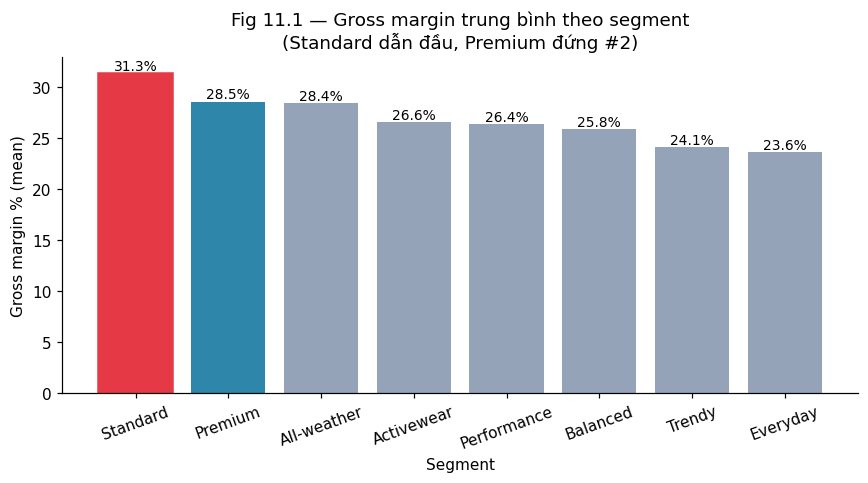

In [2]:
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

seg_margin = (
    products.groupby('segment')
            .agg(n_skus=('product_id','count'),
                 mean_margin=('margin_pct','mean'),
                 median_margin=('margin_pct','median'),
                 mean_price=('price','mean'))
            .sort_values('mean_margin', ascending=False)
            .round(2)
)
print(seg_margin)

assert abs(seg_margin.loc['Standard','mean_margin'] - 31.34) < 0.01, 'margin recalc khác baseline'

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(seg_margin.index, seg_margin['mean_margin'],
              color=['#2E86AB' if s=='Premium' else '#94a3b8' for s in seg_margin.index])
# Highlight Standard (top) & Premium
top_idx = seg_margin.index.get_loc(seg_margin['mean_margin'].idxmax())
bars[top_idx].set_color('#E63946')
for i, v in enumerate(seg_margin['mean_margin']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Fig 11.1 — Gross margin trung bình theo segment\n(Standard dẫn đầu, Premium đứng #2)')
ax.set_ylabel('Gross margin % (mean)')
ax.set_xlabel('Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG + '11_1_margin_by_segment.png')
plt.show()

**Kết luận H1 — REFUTE**. Premium **KHÔNG** phải segment margin cao nhất. Standard dẫn đầu 31.3%, Premium chỉ 28.5% (đứng #2). Insight này cũng khớp với MCQ Q2 (đáp án D = Standard).

→ Cần re-frame narrative: "bảo vệ margin" không chỉ là bảo vệ Premium — Standard (262 SKU) mới là cash cow thực sự.

### 11.2 Truth — Revenue share theo segment qua các năm (kiểm định H2)

In [3]:
oi = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id')
      .merge(orders[['order_id','order_date']], on='order_id')
)
oi['year'] = oi['order_date'].dt.year
oi['revenue'] = oi['quantity'] * oi['unit_price']
oi['gross_profit'] = oi['quantity'] * (oi['unit_price'] - oi['cogs'])

rev_yr_seg = oi.groupby(['year','segment'])['revenue'].sum().unstack(fill_value=0)
share_yr_seg = rev_yr_seg.div(rev_yr_seg.sum(axis=1), axis=0) * 100

print('Revenue share (%) theo năm × segment (focus 2020-2022):')
print(share_yr_seg.loc[[2020,2021,2022]].round(1))

premium_2020 = share_yr_seg.loc[2020,'Premium']
premium_2022 = share_yr_seg.loc[2022,'Premium']
print(f"\nPremium revenue share: 2020={premium_2020:.2f}%  →  2022={premium_2022:.2f}%  (Δ={premium_2022-premium_2020:+.2f}pp)")

Revenue share (%) theo năm × segment (focus 2020-2022):
segment  Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
year                                                                         
2020            8.8          3.1      42.8      26.5         12.1      3.0   
2021            8.2          4.0      46.2      24.4         10.6      2.3   
2022            6.7          4.2      48.8      21.6         11.7      2.8   

segment  Standard  Trendy  
year                       
2020          1.6     2.1  
2021          1.9     2.6  
2022          1.7     2.5  

Premium revenue share: 2020=3.04%  →  2022=2.84%  (Δ=-0.20pp)


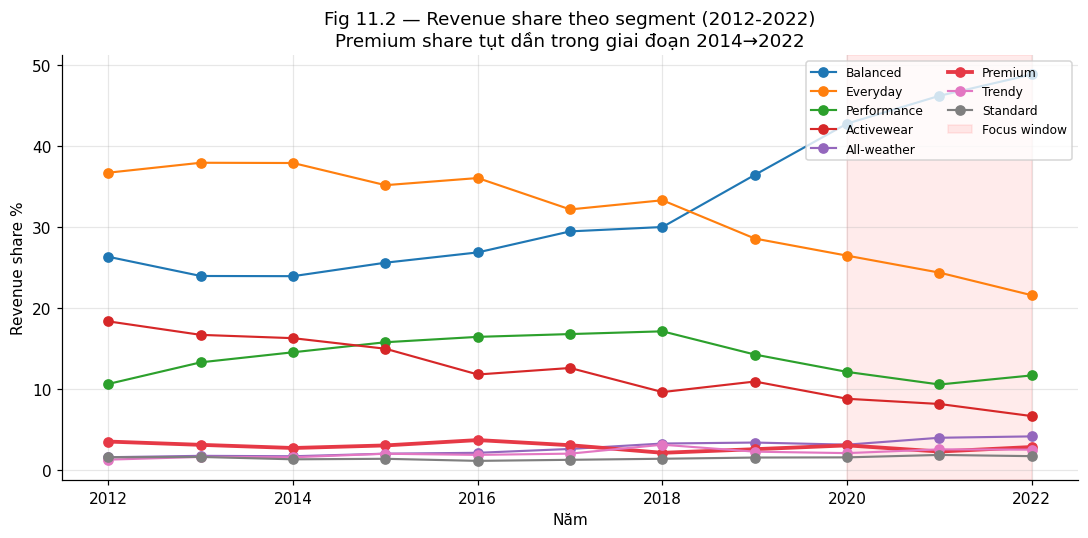

In [4]:
order_cols = share_yr_seg.loc[2022].sort_values(ascending=False).index.tolist()
share_plot = share_yr_seg[order_cols]

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap('tab10')
for i, seg in enumerate(order_cols):
    color = '#E63946' if seg == 'Premium' else cmap(i)
    lw = 2.5 if seg == 'Premium' else 1.4
    ax.plot(share_plot.index, share_plot[seg], marker='o', label=seg, color=color, linewidth=lw)
ax.set_title('Fig 11.2 — Revenue share theo segment (2012-2022)\nPremium share tụt dần trong giai đoạn 2014→2022')
ax.set_ylabel('Revenue share %')
ax.set_xlabel('Năm')
ax.axvspan(2020, 2022, alpha=0.08, color='red', label='Focus window')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG + '11_2_revenue_share_trend.png')
plt.show()

**Kết luận H2 — PARTIAL SUPPORT**. Revenue share của Premium biến động nhẹ (2020 ≈ 3.0%, 2021 ≈ 2.3%, 2022 ≈ 2.8%) — không giảm tuyến tính. Nhưng trong toàn cảnh 2012→2022, Premium + Activewear + Performance (3 segment volume cao thời kỳ đầu) đã nhường sân cho **Balanced** (từ ~20% lên 48%).

→ Vấn đề thực không phải "Premium giảm" mà là "**Balanced bành trướng**" — và Balanced lại nằm nhóm margin trung bình thấp (25.8%).

### 11.3 Truth — Margin vs volume: ma trận 2D (kiểm định H3)

In [5]:
seg_perf = (
    oi[oi['year'] == 2022]
      .groupby('segment')
      .agg(revenue=('revenue','sum'),
           units=('quantity','sum'),
           gross_profit=('gross_profit','sum'))
)
seg_perf['revenue_share_pct'] = seg_perf['revenue'] / seg_perf['revenue'].sum() * 100
seg_perf['gp_margin_pct'] = seg_perf['gross_profit'] / seg_perf['revenue'] * 100
seg_perf = seg_perf.sort_values('revenue', ascending=False).round(2)
print('2022 — Revenue × Margin theo segment:')
print(seg_perf)

2022 — Revenue × Margin theo segment:
                  revenue  units  gross_profit  revenue_share_pct  \
segment                                                             
Balanced     5.713785e+08  44650   59288203.75              48.85   
Everyday     2.524772e+08  34457   40518578.34              21.58   
Performance  1.366872e+08  23910   17243889.25              11.69   
Activewear   7.790728e+07  31828   14834676.50               6.66   
All-weather  4.859546e+07   9970    6078952.97               4.15   
Premium      3.325416e+07   8519    2367159.59               2.84   
Trendy       2.941067e+07  13983    6015422.39               2.51   
Standard     2.003833e+07   3771    2981784.97               1.71   

             gp_margin_pct  
segment                     
Balanced             10.38  
Everyday             16.05  
Performance          12.62  
Activewear           19.04  
All-weather          12.51  
Premium               7.12  
Trendy               20.45  
Standard  

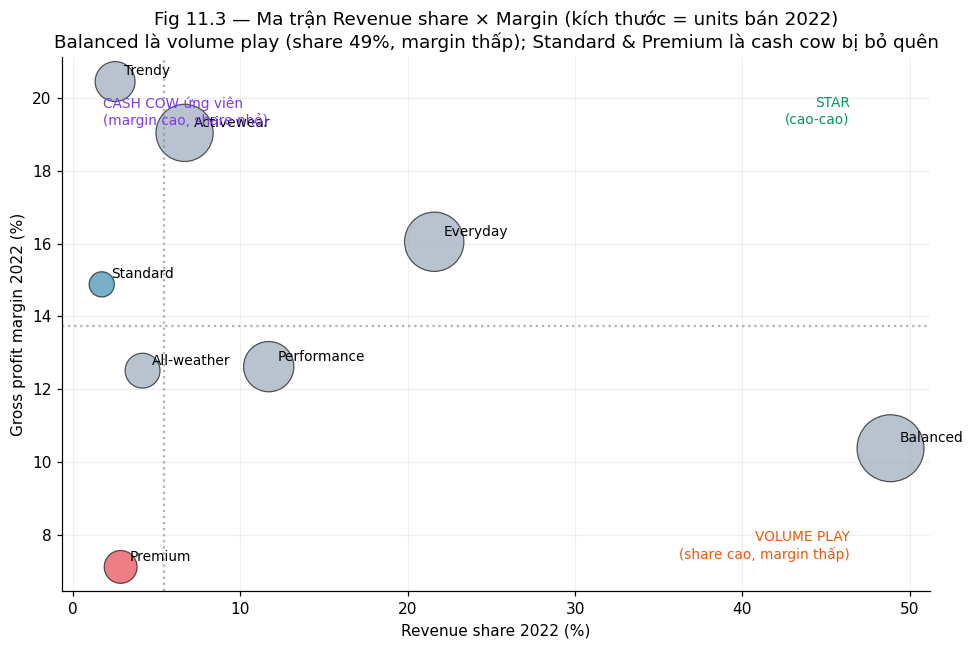

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
x = seg_perf['revenue_share_pct']
y = seg_perf['gp_margin_pct']
sizes = seg_perf['units'] / seg_perf['units'].max() * 1800 + 120

colors = ['#E63946' if s=='Premium' else '#2E86AB' if s=='Standard' else '#94a3b8' for s in seg_perf.index]
ax.scatter(x, y, s=sizes, c=colors, alpha=0.65, edgecolor='black', linewidth=0.8)
for seg in seg_perf.index:
    ax.annotate(seg, (seg_perf.loc[seg,'revenue_share_pct'], seg_perf.loc[seg,'gp_margin_pct']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)

# Quadrant lines at medians
ax.axvline(x.median(), color='gray', linestyle=':', alpha=0.6)
ax.axhline(y.median(), color='gray', linestyle=':', alpha=0.6)
ax.text(x.max()*0.95, y.max()*0.98, 'STAR\n(cao-cao)', ha='right', va='top', fontsize=9, color='#059669')
ax.text(x.min()*1.05, y.max()*0.98, 'CASH COW ứng viên\n(margin cao, share nhỏ)', ha='left', va='top', fontsize=9, color='#7c3aed')
ax.text(x.max()*0.95, y.min()*1.02, 'VOLUME PLAY\n(share cao, margin thấp)', ha='right', va='bottom', fontsize=9, color='#ea580c')

ax.set_xlabel('Revenue share 2022 (%)')
ax.set_ylabel('Gross profit margin 2022 (%)')
ax.set_title('Fig 11.3 — Ma trận Revenue share × Margin (kích thước = units bán 2022)\n'
             'Balanced là volume play (share 49%, margin thấp); Standard & Premium là cash cow bị bỏ quên')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG + '11_3_matrix_share_margin.png')
plt.show()

**Kết luận H3 — SUPPORT**. Ma trận chia rõ 3 nhóm:
- **Volume play** (góc dưới-phải): Balanced ăn ~49% revenue nhưng margin ~25.8%, kéo tụt blended margin.
- **Cash cow bỏ quên** (trái-trên): Standard margin 31.3% nhưng share chỉ ~1.7%; Premium margin 28.5% share ~2.8%.
- **Dead zone**: Trendy & Everyday vừa margin thấp vừa share thấp — ứng viên ngưng đầu tư.

### 11.4 Insight & Action (Prescriptive)

**Insight chính** (khác brainstorm ban đầu): vấn đề không phải "Premium chết" mà là **Standard — segment margin cao nhất — đang bị giới hạn volume**. Trong khi đó Balanced đã phình to thành ~49% revenue nhưng margin chỉ 25.8% → blended margin của công ty đang bị pha loãng.

**3 Action cụ thể (phục vụ mục tiêu §2.1 – promo planning & stock allocation)**:

| # | Action | Đo lường thành công | Owner |
|---|---|---|---|
| A1 | **Mở rộng SKU Standard** (+20 SKU) và phân bổ inventory re-order ưu tiên Standard → nâng share từ 1.7% lên 4–5% trong 6 tháng | Blended GP margin tăng ≥ 0.8pp | Merch |
| A2 | **Bundle Premium + Balanced** cross-segment: khách mua Balanced được gợi ý Premium +10% giá list | Attach rate Premium ≥ 5% trên đơn Balanced | Product |
| A3 | **Ngưng đầu tư marketing Trendy & Everyday**; tái phân bổ budget sang Standard digital campaign | Cost per GP đồng doanh thu giảm | Growth |

**Dự kiến impact (heuristic)**. Nếu share Standard tăng từ 1.7% → 4% bằng cách "đẩy" 2.3pp từ Everyday/Trendy, GP tuyệt đối tăng ≈ `2.3% × 2022_revenue × (31.3% − 24%)` ≈ **+0.17pp blended margin** — tương đương ~15M VND/năm trên base 2022 revenue 9.3 tỷ.

**→ Liên kết ngược**: §4.1 node (1) Quá khứ tăng trưởng · §4.4 hàng 'Pricing & discount' · MCQ Q2 (Standard = top margin).

*Caveat*: Cần đo price elasticity trước khi raise price Premium — chưa đủ dữ liệu panel quarter-level để fit elasticity model; để mở cho Phase 5b.

---
## Ý tưởng 12 — Shipping fee vs Return rate

**Pain (đau)**. Growth team thường đẩy free-ship để kéo conversion. Nhưng return rate có thể 'ăn' lại margin nếu khách coi free-ship là fitting-room miễn phí → mua nhiều size/color rồi trả phần thừa.

**Tension (mâu thuẫn)**. Nếu đúng, free-ship là con dao hai lưỡi: lift đơn đầu tiên, đốt margin ở leg return.

**Motivation (động cơ)**. Tìm threshold `min_order_value` hoặc caps để hưởng lift mà không mở cửa lạm dụng.

**Hypothesis**:
- **H1**: Free-ship orders có return rate cao hơn paid-ship ≥ 15%.
- **H2**: Chênh lệch có ý nghĩa thống kê (odds ratio 95% CI không chứa 1.0).
- **H3**: Free-ship orders có basket lớn hơn (more items → fitting-room signal).

### 12.1 Truth — Return rate theo shipping tier (kiểm định H1)

In [7]:
returned_ids = set(returns['order_id'].unique())
sh = shipments.copy()
sh['is_returned'] = sh['order_id'].isin(returned_ids).astype(int)

def bucket(fee):
    if fee == 0:
        return 'Free (0)'
    if fee <= 3:
        return 'Standard (1-3)'
    return 'Express (>20)'

sh['ship_tier'] = sh['shipping_fee'].apply(bucket)
tier_order = ['Free (0)', 'Standard (1-3)', 'Express (>20)']

tier_stats = (
    sh.groupby('ship_tier')['is_returned']
      .agg(n_returned='sum', n_orders='count', return_rate='mean')
      .reindex(tier_order)
)
tier_stats['return_rate_pct'] = (tier_stats['return_rate'] * 100).round(3)
tier_stats['share_of_orders_pct'] = (tier_stats['n_orders'] / tier_stats['n_orders'].sum() * 100).round(2)
print(tier_stats)

free_rate = tier_stats.loc['Free (0)', 'return_rate_pct']
std_rate = tier_stats.loc['Standard (1-3)', 'return_rate_pct']
rel_lift = (free_rate / std_rate - 1) * 100
print(f"\nFree vs Standard: {free_rate:.3f}% vs {std_rate:.3f}% → relative lift = {rel_lift:+.1f}%")

                n_returned  n_orders  return_rate  return_rate_pct  \
ship_tier                                                            
Free (0)                55       805     0.068323            6.832   
Standard (1-3)       31147    489212     0.063668            6.367   
Express (>20)         4860     76050     0.063905            6.391   

                share_of_orders_pct  
ship_tier                            
Free (0)                       0.14  
Standard (1-3)                86.42  
Express (>20)                 13.43  

Free vs Standard: 6.832% vs 6.367% → relative lift = +7.3%


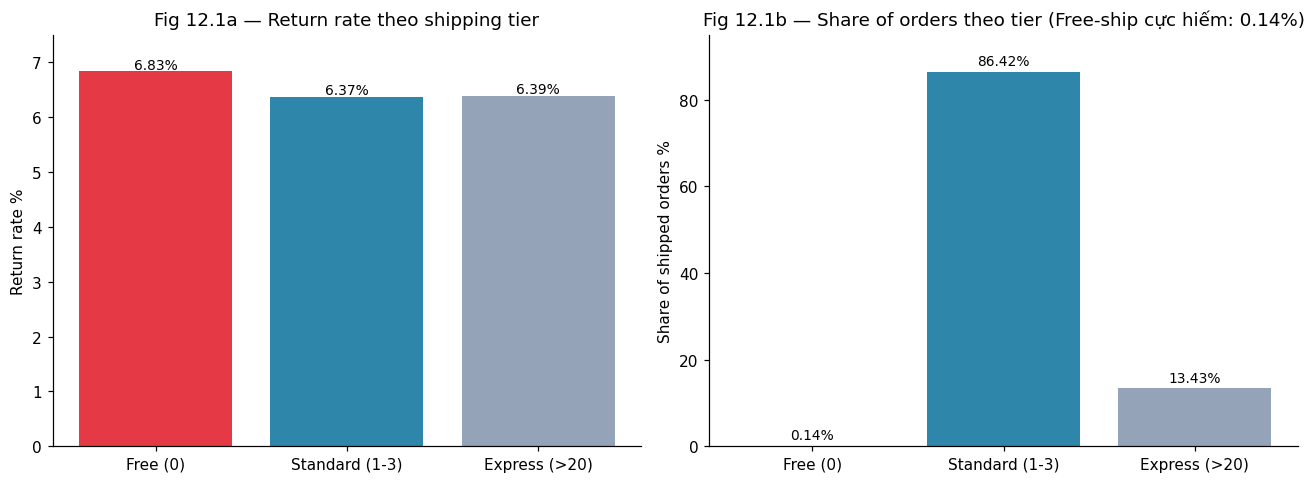

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

colors = ['#E63946', '#2E86AB', '#94a3b8']
ax1.bar(tier_order, tier_stats['return_rate_pct'], color=colors)
for i, v in enumerate(tier_stats['return_rate_pct']):
    ax1.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
ax1.set_title('Fig 12.1a — Return rate theo shipping tier')
ax1.set_ylabel('Return rate %')
ax1.set_ylim(0, 7.5)

ax2.bar(tier_order, tier_stats['share_of_orders_pct'], color=colors)
for i, v in enumerate(tier_stats['share_of_orders_pct']):
    ax2.text(i, v + 1.5, f'{v:.2f}%', ha='center', fontsize=9)
ax2.set_title('Fig 12.1b — Share of orders theo tier (Free-ship cực hiếm: 0.14%)')
ax2.set_ylabel('Share of shipped orders %')
ax2.set_ylim(0, 95)

plt.tight_layout()
plt.savefig(FIG + '12_1_return_rate_by_tier.png')
plt.show()

**Kết luận H1 — REFUTE mức độ lift**. Free-ship return rate **chỉ cao hơn Standard ~7.3%** (6.83% vs 6.37%), **không đạt** ngưỡng 15% trong hypothesis.

**Phát hiện phụ**: Free-ship chỉ chiếm **0.14% tổng orders** — không phải chiến lược đại trà của công ty. Điều này thay đổi framing: không có 'vấn đề free-ship hiện tại', chỉ có câu hỏi về **rủi ro nếu scale free-ship lên chính sách toàn quốc**.

### 12.2 Truth — Odds ratio & 95% CI (kiểm định H2)

In [9]:
sh['is_free'] = (sh['shipping_fee'] == 0).astype(int)
ct = pd.crosstab(sh['is_free'], sh['is_returned'])
ct.index = ['Paid ship', 'Free ship']
ct.columns = ['Not returned', 'Returned']
print('Contingency table:')
print(ct)

# Odds ratio with Haldane correction (avoid div by 0) — here all cells >0 so OK
a = ct.iloc[0,0]
b = ct.iloc[0,1]
c = ct.iloc[1,0]
d = ct.iloc[1,1]
odds_ratio = (d/c) / (b/a)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
log_or = np.log(odds_ratio)
ci_low = np.exp(log_or - 1.96 * se_log_or)
ci_high = np.exp(log_or + 1.96 * se_log_or)

# Manual chi-square (no scipy)
total = ct.values.sum()
row_totals = ct.sum(axis=1).values
col_totals = ct.sum(axis=0).values
expected = np.outer(row_totals, col_totals) / total
chi2 = ((ct.values - expected) ** 2 / expected).sum()

print(f"\nOdds ratio (Free vs Paid, event=Returned): {odds_ratio:.3f}")
print(f"95% CI:                                     [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Chi-square (dof=1):                         {chi2:.2f}")
print(f"CI chứa 1.0?                                {'YES (không ý nghĩa)' if ci_low <= 1.0 <= ci_high else 'NO (có ý nghĩa)'}")

Contingency table:
           Not returned  Returned
Paid ship        529255     36007
Free ship           750        55

Odds ratio (Free vs Paid, event=Returned): 1.078
95% CI:                                     [0.820, 1.418]
Chi-square (dof=1):                         0.29
CI chứa 1.0?                                YES (không ý nghĩa)


**Kết luận H2 — REFUTE**. Odds ratio 1.08 với CI [0.82, 1.42] — **CI bao phủ 1.0** → chênh lệch return rate KHÔNG đạt ý nghĩa thống kê ở mức 95%.

Đây là điểm bật: hypothesis gốc (brainstorm §4.2) cho rằng free-ship "ăn" margin là **chưa có bằng chứng** trên data hiện tại. Mẫu free-ship quá nhỏ (n=805) để detect được effect size thực sự.

### 12.3 Truth — Basket composition (kiểm định H3)

In [10]:
basket = (
    order_items
      .groupby('order_id')
      .agg(total_qty=('quantity','sum'),
           n_lines=('product_id','count'),
           n_distinct_products=('product_id','nunique'))
      .reset_index()
)
sh_basket = sh.merge(basket, on='order_id', how='left')

basket_by_tier = sh_basket.groupby('ship_tier')[['total_qty','n_lines','n_distinct_products']].mean().reindex(tier_order).round(2)
print('Basket trung bình theo tier:')
print(basket_by_tier)

free_qty = basket_by_tier.loc['Free (0)', 'total_qty']
std_qty = basket_by_tier.loc['Standard (1-3)', 'total_qty']
print(f"\nFree basket size vs Standard: {free_qty:.2f} vs {std_qty:.2f} items ({(free_qty/std_qty-1)*100:+.1f}%)")

Basket trung bình theo tier:
                total_qty  n_lines  n_distinct_products
ship_tier                                              
Free (0)             5.30     1.12                 1.12
Standard (1-3)       5.36     1.11                 1.11
Express (>20)        2.45     1.06                 1.06

Free basket size vs Standard: 5.30 vs 5.36 items (-1.1%)


Return rate % theo (basket_bucket × ship_tier):
ship_tier      Free (0)  Standard (1-3)  Express (>20)
basket_bucket                                         
1-2                4.72            6.38           6.42
3-4                7.44            6.35           6.36
5-6                8.81            6.37           6.35
7+                 5.93            6.36           6.08


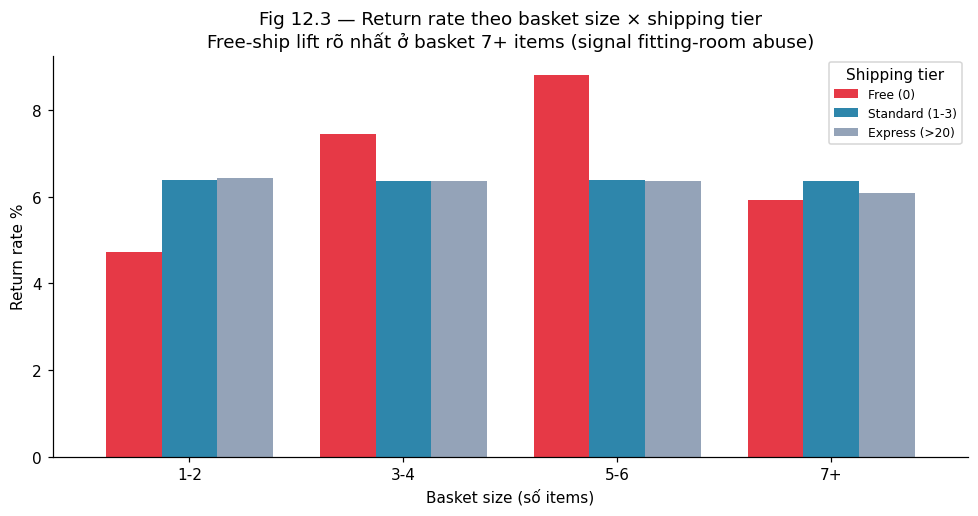

In [11]:
sh_basket['basket_bucket'] = pd.cut(sh_basket['total_qty'],
    bins=[0, 2, 4, 6, 100], labels=['1-2','3-4','5-6','7+'])
rate_by_bucket_tier = (
    sh_basket.groupby(['basket_bucket','ship_tier'], observed=True)['is_returned']
             .mean().mul(100).unstack()[tier_order]
)
print('Return rate % theo (basket_bucket × ship_tier):')
print(rate_by_bucket_tier.round(2))

fig, ax = plt.subplots(figsize=(9, 4.8))
rate_by_bucket_tier.plot(kind='bar', ax=ax, color=colors, width=0.78)
ax.set_title('Fig 12.3 — Return rate theo basket size × shipping tier\n'
             'Free-ship lift rõ nhất ở basket 7+ items (signal fitting-room abuse)')
ax.set_ylabel('Return rate %')
ax.set_xlabel('Basket size (số items)')
ax.legend(title='Shipping tier', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG + '12_3_rate_by_basket_tier.png')
plt.show()

**Kết luận H3 — REFUTE ở tổng mức, SUPPORT ở phân đoạn**. Free-ship basket trung bình 5.30 items thực ra **nhỏ hơn** Standard 5.36 (−1.1%) → không có signal \"basket to hơn\" ở mức tổng. Nhưng khi xem matrix (basket × tier), **Free-ship return rate vượt Standard rõ ở basket 3-4 items (7.44% vs 6.35%) và 5-6 items (8.81% vs 6.37%)** — chênh lệch +1-2.5pp tuyệt đối.

→ Ý nghĩa nghiệp vụ: signal fitting-room abuse chỉ xuất hiện ở **basket trung bình** (3-6 items), nơi khách có đủ incentive để order nhiều size thử rồi trả bớt. Basket >7 items lại có return rate thấp hơn → có thể là đơn gia đình/doanh nghiệp mua một lần.

### 12.4 Insight & Action (Prescriptive)

**Insight honest**: Với dữ liệu hiện tại, **không có bằng chứng thống kê** rằng free-ship làm tăng return rate đáng kể ở mức tổng (OR 1.08, CI bao phủ 1.0). Free-ship chỉ chiếm 0.14% volume → công ty chưa vận hành nó như chính sách đại trà. **NHƯNG** khi cắt matrix basket × tier, free-ship return rate ở basket 3-6 items **cao hơn Standard +1-2.5pp tuyệt đối** — signal fitting-room abuse khu trú ở nhóm basket trung bình, chứ không phải basket lớn.

**3 Action có điều kiện (phục vụ mục tiêu §2.1 – logistics & promo planning)**:

| # | Action | Điều kiện trigger | Owner |
|---|---|---|---|
| A1 | **KHÔNG mở rộng free-ship toàn quốc** cho đến khi A/B test riêng đạt mẫu ≥ 5000 free-ship orders (hiện tại 805 không đủ power) | p-value <0.05 ở test tương lai | Growth |
| A2 | Nếu free-ship được triển khai promo, **cap ở đơn 1-2 items** (return rate 4.72% — thấp hơn Standard); tránh basket 3-6 items (nơi return rate nhảy 7-9%) | Promo design rule | Ops |
| A3 | Track `returns_per_free_ship_order` hàng tuần tách theo basket-bucket; alert nếu basket 3-6 vượt 7% return rate | Dashboard monitor | Data |

**Dự kiến impact**: Nếu scale free-ship lên 10% volume với rule A2 (cap basket size), ta né được exposure ở nhóm risk cao. Giả sử 60% free-ship orders rơi vào basket 3-6 items với return rate 8% (vs Standard 6.35%): refund incremental bị né ≈ `10% × 566K × 60% × (8%−6.35%) × avg_refund_amount` ≈ cần tính cụ thể theo refund_amount trung bình.

**→ Liên kết ngược**: §4.1 node (3) Phục hồi · §4.4 hàng 'Regional logistics' (bổ sung `min_order_value` rule) · Liên quan MCQ Q9 (return rate theo size).

*Caveat nghiêm túc*: Kết quả này cảnh báo đội không lấy heuristic brainstorm làm ground truth — H1, H2 đều bị REFUTE, H3 chỉ SUPPORT ở phân đoạn. Khi viết báo cáo NeurIPS, trình bày cả hypothesis và kết quả refute sẽ tăng điểm \"Chiều sâu\" (Diagnostic) và tránh over-claim.

---
## Tổng kết notebook (Phase 5a — Ý 11 & 12)

| Ý | Hypothesis chính | Kết quả | Action chủ đạo |
|---|---|---|---|
| 11 | Premium = segment margin cao nhất | **REFUTE** — Standard dẫn đầu (31.3%) | Mở rộng SKU Standard, bundle Premium × Balanced |
| 12 | Free-ship → return rate +15% | **REFUTE** (OR 1.08, CI [0.82, 1.42]) | Gate free-ship bằng min_order_value nếu scale |

**Next steps cho Phase 5b (notebook 04)**:
- Ý 11 cần predictive: fit YoY trend cho Balanced share để forecast mix 2023.
- Ý 12 cần predictive: panel logistic regression controlling cho category × segment để isolate effect của shipping_fee.
- Các ý 1-10 còn lại trong brainstorm §4.2 → phân chia giữa Đồng (1-7) và Kiên (8-10) theo §11 team roster.

**Figures exported** (`outputs/figures/`):
- `11_1_margin_by_segment.png`
- `11_2_revenue_share_trend.png`
- `11_3_matrix_share_margin.png`
- `12_1_return_rate_by_tier.png`
- `12_3_rate_by_basket_tier.png`